In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/rama_2017.csv'
df = pd.read_csv (ruta,parse_dates = True, index_col= 0, sep=',')
df.head()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
fecha,,,,,,,,
2017-01-01,0.786278,10.640708,23.246018,33.861947,32.500627,71.893905,43.988669,2.300730
2017-01-02,0.843639,25.946333,34.887299,60.772809,27.163085,48.914747,22.729167,3.489614
2017-01-03,0.988033,33.498175,41.976277,75.507299,31.186528,67.152273,32.447674,14.315634
2017-01-04,0.899530,36.619224,36.517560,73.133087,23.891165,59.255708,24.497126,6.131462
2017-01-05,1.058875,39.865510,40.136659,80.026030,28.334320,70.328431,31.270440,4.196429


In [ ]:
print(df.index.dtype)

datetime64[ns]


In [ ]:
df.describe()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,0.582467,16.453825,25.446013,41.893415,31.039960,45.429294,22.731652,4.647623
std,0.185718,9.575924,7.578497,16.495855,9.402720,17.827721,9.183796,4.229699
min,0.228821,2.817185,11.964059,15.418605,11.781984,11.842900,6.053719,0.865260
25%,0.436364,9.085714,18.986555,28.806452,23.848200,29.903047,15.815934,1.998466
50%,0.564544,13.751620,24.828571,38.007859,30.357055,44.374207,21.940341,3.188088
75%,0.709202,22.351190,29.691532,51.622540,36.506596,59.709007,28.599440,5.545312
max,1.233152,56.657895,53.279904,109.968900,64.890879,108.784091,51.461741,25.400556


In [ ]:
df.describe().T #para cambiar los contaminantes y los datos de lugar

,count,mean,std,min,25%,50%,75%,max
CO,365.0,0.582467,0.185718,0.228821,0.436364,0.564544,0.709202,1.233152
NO,365.0,16.453825,9.575924,2.817185,9.085714,13.751620,22.351190,56.657895
NO2,365.0,25.446013,7.578497,11.964059,18.986555,24.828571,29.691532,53.279904
NOX,365.0,41.893415,16.495855,15.418605,28.806452,38.007859,51.622540,109.968900
O3,365.0,31.039960,9.402720,11.781984,23.848200,30.357055,36.506596,64.890879
PM10,365.0,45.429294,17.827721,11.842900,29.903047,44.374207,59.709007,108.784091
PM25,365.0,22.731652,9.183796,6.053719,15.815934,21.940341,28.599440,51.461741
SO2,365.0,4.647623,4.229699,0.865260,1.998466,3.188088,5.545312,25.400556


In [ ]:
df.isna().sum() #para revisar datos nulos

,0
CO,0
NO,0
NO2,0
NOX,0
O3,0
PM10,0
PM25,0
SO2,0


**ESTACIONAREIDAD**

La estacionariedad es una propiedad fundamental en series de tiempo donde sus características estadísticas—media, varianza y estructura de autocorrelación—permanecen constantes a lo largo del tiempo.

**TIPOS DE ESTACIONARIEDAD**

* tendencia
* estacionalidad
* cambios en la varianza
* cambios estructurales


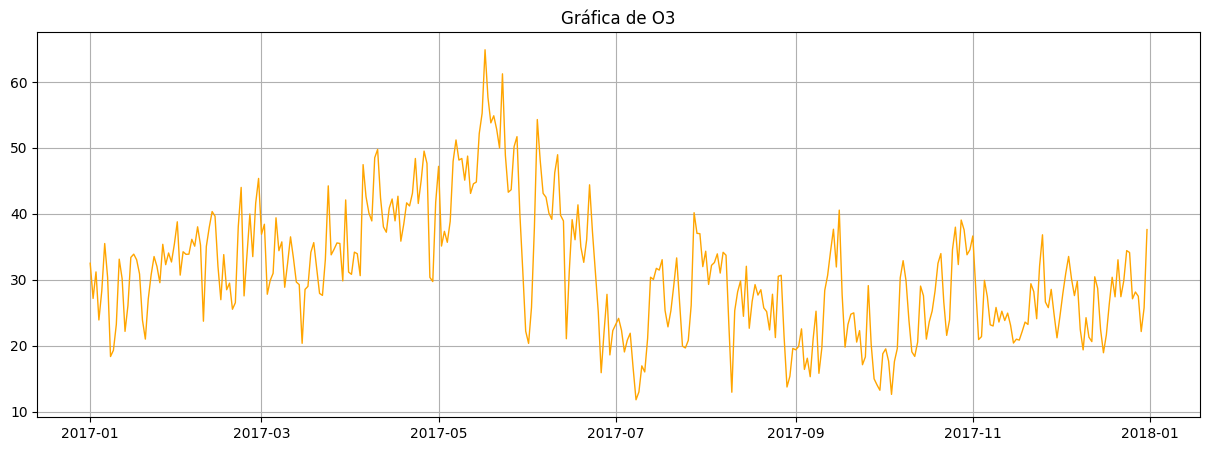

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['O3'], lw =1, color = 'orange')
plt.title('Gráfica de O3')
plt.grid(True)
plt.show()

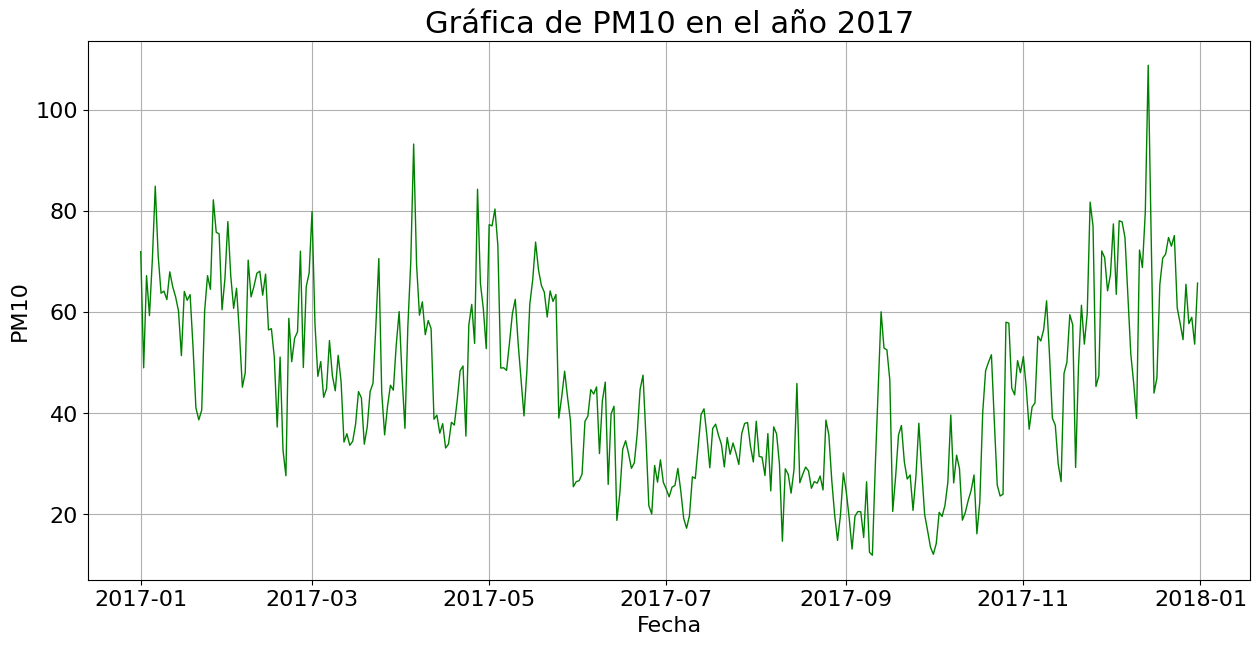

In [ ]:
fig, ax = plt.subplots(figsize=(15,7), dpi=100)

ax.plot(df['PM10'], lw=1, color='green')
ax.set_title('Gráfica de PM10 en el año 2017', fontsize=22)
ax.set_xlabel('Fecha', fontsize=16)
ax.set_ylabel('PM10', fontsize=16)

#cambiar el tamaño de ñetra de los numeros en ambos ejes
ax.tick_params(labelsize=16)

ax.grid(True)

plt.show()


interpretacion visual

la serie de PM10 no parece estacionaria, ya que presenta cambios en su nivel medio a lo largo del tiempo. en particular se observan valores mas altos al inicio y al final del año y menores en la parte media.

# Task
Calculate the monthly mean and variance of the `PM10` column from the `df` DataFrame, visualize these monthly statistics using appropriate plots, and finally, summarize the observed trends in the monthly mean and variance of PM10. Additionally, explain how the concept of covariance would be applied in the context of this time series data.

## Calcular la media y varianza mensual de PM10

### Subtask:
Utiliza la función resample de pandas para agrupar los datos de PM10 por mes y calcula la media y la varianza para cada periodo.


**Reasoning**:
The subtask requires calculating the monthly mean and variance for the 'PM10' column. I will use the `resample` function to group the data by month and then apply `mean()` and `var()` to get the desired statistics, storing them in new variables.



## Summarize Trends in Monthly Statistics

### Subtask:
Analyze the generated plots to describe the observed trends in the monthly mean and variance of 'PM10'. Discuss any patterns, seasonality, or significant changes throughout the year.

**Analysis of Monthly Mean of PM10:**

*   **High Concentrations:** The monthly mean of PM10 shows higher concentrations at the beginning of the year (January, February) and towards the end of the year (November, December). December records the highest mean PM10 value.
*   **Low Concentrations:** The lowest monthly mean concentrations are observed during the middle of the year, particularly from June to September.
*   **Seasonal Pattern:** There is a clear seasonal pattern, with higher PM10 levels in colder months (winter) and lower levels in warmer months (summer). This might indicate factors like increased heating, specific weather conditions, or atmospheric inversions during winter months that trap pollutants.

**Analysis of Monthly Variance of PM10:**

*   **High Variability:** The variance is notably high in April, May, and then again towards the end of the year (September to December). This suggests that during these periods, the PM10 levels fluctuate more significantly within the month.
*   **Low Variability:** The variance is considerably lower during the summer months (June, July, August), indicating more stable PM10 levels day-to-day within those months.

**Overall Trends and Seasonality:**

*   **Inverse Relationship (generally):** While not perfectly inverse, there's a general trend where months with higher mean PM10 (e.g., winter) also tend to have higher variance, suggesting not only higher pollution but also greater day-to-day fluctuation. Conversely, months with lower mean PM10 (e.g., summer) tend to have lower variance, indicating more consistent low pollution levels.
*   **Peak Periods:** Both mean and variance show peaks at the start and end of the year, consistent with seasonal influences. The dip in both during summer months suggests improved air quality and stability during that period.
*   **Specific Observations:** April and May show relatively high variance even before the highest mean values of winter, which could indicate intermittent pollution events or changing atmospheric conditions during the spring. December exhibits both the highest mean and a high variance, indicating consistently high and fluctuating pollution.

## Explaining Covariance in Time Series Data

Covariance measures the extent to which two variables change together. In the context of time series data like the `PM10` column, covariance can be applied in several ways:

1.  **Covariance between different pollutants:** We could calculate the covariance between `PM10` and other pollutants (e.g., `CO`, `NO2`, `O3`). A positive covariance would suggest that as `PM10` levels increase, the levels of the other pollutant also tend to increase. A negative covariance would suggest an inverse relationship.

2.  **Autocovariance (Covariance of a time series with itself at different lags):** This is a crucial concept in time series analysis. Autocovariance measures how much a time series is correlated with a lagged version of itself. For example, we could calculate the covariance between `PM10` at time `t` and `PM10` at time `t-1` (one day lag), `t-7` (one week lag), or `t-30` (one month lag).
    *   **Positive autocovariance at a given lag** indicates that high values in the series tend to be followed by high values (and low by low) at that lag, suggesting persistence or trends.
    *   **Negative autocovariance** indicates that high values tend to be followed by low values (and vice-versa), suggesting oscillatory or mean-reverting behavior.
    *   **Autocovariance is a key component of stationarity analysis**; a stationary time series has a constant autocovariance structure over time.

3.  **Cross-covariance:** This is similar to autocovariance but measures the covariance between one time series and a lagged version of *another* time series. For instance, we could analyze the cross-covariance between `NO2` at time `t` and `PM10` at time `t+1` to see if `NO2` levels influence `PM10` levels in the future.

In summary, covariance helps us understand the relationships within a single time series over time (autocovariance) and between different time series (covariance and cross-covariance), which is fundamental for modeling and forecasting air quality data.


## Summarize Trends in Monthly Statistics

### Subtask:
Analyze the generated plots to describe the observed trends in the monthly mean and variance of 'PM10'. Discuss any patterns, seasonality, or significant changes throughout the year.


## Calculando Media, Varianza y Autocovarianza para Tramos Específicos de PM10

Ahora vamos a dividir los datos de `PM10` en tramos (por ejemplo, trimestres) para calcular la media, varianza y autocovarianza (con un retardo de 1 día) para cada uno.

In [ ]:
# Definir los tramos (trimestres como ejemplo)
tramos = {
    'Q1_2017': ('2017-01-01', '2017-03-31'),
    'Q2_2017': ('2017-04-01', '2017-06-30'),
    'Q3_2017': ('2017-07-01', '2017-09-30'),
    'Q4_2017': ('2017-10-01', '2017-12-31')
}

print('Estadísticas de PM10 por Tramos:')
for tramo_nombre, (start_date, end_date) in tramos.items():
    print(f'\n--- {tramo_nombre} ({start_date} a {end_date}) ---')

    # Seleccionar el tramo de datos
    pm10_tramo = df['PM10'].loc[start_date:end_date]

    # Calcular media
    mean_pm10 = pm10_tramo.mean()
    print(f'Media de PM10: {mean_pm10:.2f}')

    # Calcular varianza
    var_pm10 = pm10_tramo.var()
    print(f'Varianza de PM10: {var_pm10:.2f}')

    # Calcular autocovarianza (con un retardo de 1 día)
    # La autocovarianza es la covarianza de la serie consigo misma en un retardo dado.
    # Usamos .autocorr(lag=1) que devuelve la autocorrelación,
    # y para la autocovarianza necesitamos la varianza y la autocorrelación.
    # Autocovarianza(lag) = Varianza * Autocorrelacion(lag)
    # Asegúrate de que el tramo tenga suficientes datos para el lag
    if len(pm10_tramo) > 1:
        autocorr_lag1 = pm10_tramo.autocorr(lag=1)
        # Autocovarianza = Varianza * Autocorrelacion
        # Para obtener la autocovarianza directamente, podemos usar el método .cov() de pandas
        # de la serie original y su versión con lag.
        # Esto se calcula como la covarianza entre la serie y la serie desplazada.
        autocov_lag1 = pm10_tramo.cov(pm10_tramo.shift(1))
        print(f'Autocovarianza de PM10 (lag 1): {autocov_lag1:.2f}')
    else:
        print('No hay suficientes datos para calcular la autocovarianza en este tramo.')

Estadísticas de PM10 por Tramos:

--- Q1_2017 (2017-01-01 a 2017-03-31) ---
Media de PM10: 55.54
Varianza de PM10: 168.81
Autocovarianza de PM10 (lag 1): 112.99

--- Q2_2017 (2017-04-01 a 2017-06-30) ---
Media de PM10: 47.39
Varianza de PM10: 257.54
Autocovarianza de PM10 (lag 1): 204.09

--- Q3_2017 (2017-07-01 a 2017-09-30) ---
Media de PM10: 29.14
Varianza de PM10: 81.86
Autocovarianza de PM10 (lag 1): 52.23

--- Q4_2017 (2017-10-01 a 2017-12-31) ---
Media de PM10: 49.89
Varianza de PM10: 376.30
Autocovarianza de PM10 (lag 1): 294.73


In [81]:
serie = df['PM10'].dropna() #seleccionar la serie de interes y eliminar valors

mitad = len(serie) //2 #dividir la serie en 2 partes
tramo1=serie.iloc[:mitad]
tramo2=serie.iloc[mitad:]

print('Media tramo 1:', tramo1.mean())
print('Media tramo 2:', tramo2.mean())
print('Varianza tramo 1:', tramo1.var())
print('Varianza tramo 2:', tramo2.var())

Media tramo 1: 51.29711814238904
Media tramo 2: 39.59353510834025
Varianza tramo 1: 231.52107884839748
Varianza tramo 2: 336.7317178769674


In [82]:
serie_2 = df['O3'].dropna() #seleccionar la serie de interes y eliminar valors

mitad_1 = len(serie_2) //2 #dividir la serie en 2 partes
tramo_1=serie_2.iloc[:mitad_1]
tramo_2=serie_2.iloc[mitad_1:]

print('Media tramo 1:', tramo_1.mean())
print('Media tramo 2:', tramo_2.mean())
print('Varianza tramo 1:', tramo_1.var())
print('Varianza tramo 2:', tramo_2.var())

Media tramo 1: 36.412964512063624
Media tramo 2: 25.69631602618558
Varianza tramo 1: 80.38917008436238
Varianza tramo 2: 39.29420861390607


In [83]:
serie_3 = df['PM25'].dropna() #seleccionar la serie de interes y eliminar valors

mitad_co2 = len(serie_3) //2 #dividir la serie en 2 partes
tramo_4=serie_3.iloc[:mitad_co2]
tramo_5=serie_3.iloc[mitad_co2:]

print('Media tramo 1:', tramo_4.mean())
print('Media tramo 2:', tramo_5.mean())
print('Varianza tramo 1:', tramo_4.var())
print('Varianza tramo 2:', tramo_5.var())

Media tramo 1: 25.595223133629617
Media tramo 2: 19.883729360820663
Varianza tramo 1: 68.56904056190969
Varianza tramo 2: 84.13665490173307


In [84]:
serie_NOX = df['NOX'].dropna() #seleccionar la serie de interes y eliminar valors

mitad_NOX = len(serie_NOX) //2 #dividir la serie en 2 partes
tramo_6=serie_NOX.iloc[:mitad_NOX]
tramo_7=serie_NOX.iloc[mitad_NOX:]

print('Media tramo 1:', tramo_6.mean())
print('Media tramo 2:', tramo_7.mean())
print('Varianza tramo 1:', tramo_6.var())
print('Varianza tramo 2:', tramo_7.var())

Media tramo 1: 42.67130385037676
Media tramo 2: 41.11977731660056
Varianza tramo 1: 226.29776405604866
Varianza tramo 2: 317.96516826900364


CUANDO TENEMOS SERIE ESTACIONARIA EN MEDIA ES ESTACIONARIA DE PRIMER GRADO

SI LA MEDIA ES CONSTANTE Y LA VARIANZA CAMBIA SE LLAMA HETEROCEDASTICIDAD ES DE SEGUNDO ORDEN



In [85]:
serie_SO2 = df['SO2'].dropna() #seleccionar la serie de interes y eliminar valors

mitad_SO2 = len(serie_SO2) //2 #dividir la serie en 2 partes
tramo_8=serie_SO2.iloc[:mitad_SO2]
tramo_9=serie_SO2.iloc[mitad_SO2:]

print('Media tramo 1:', tramo_8.mean())
print('Media tramo 2:', tramo_9.mean())
print('Varianza tramo 1:', tramo_8.var())
print('Varianza tramo 2:', tramo_9.var())

Media tramo 1: 4.505464804720305
Media tramo 2: 4.789005311073682
Varianza tramo 1: 17.34554176793369
Varianza tramo 2: 18.490156813467962


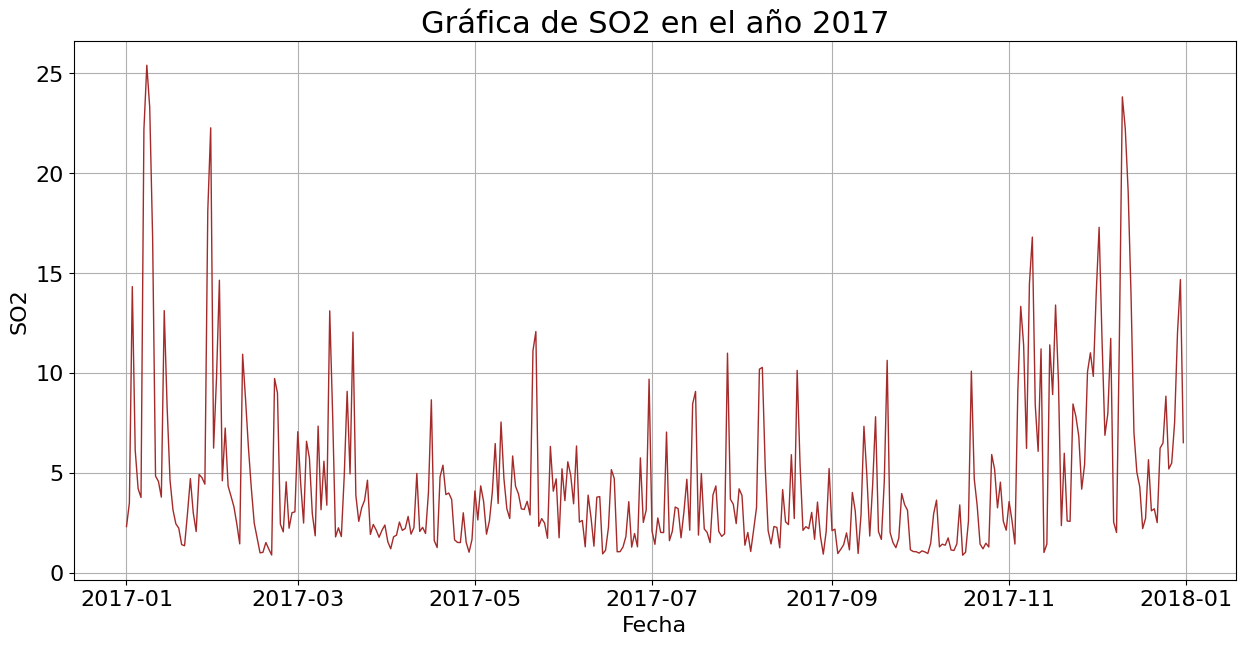

In [87]:
fig, ax = plt.subplots(figsize=(15,7), dpi=100)

ax.plot(df['SO2'], lw=1, color='BROWN')
ax.set_title('Gráfica de SO2 en el año 2017', fontsize=22)
ax.set_xlabel('Fecha', fontsize=16)
ax.set_ylabel('SO2', fontsize=16)

#cambiar el tamaño de ñetra de los numeros en ambos ejes
ax.tick_params(labelsize=16)

ax.grid(True)

plt.show()


estacionalidad

son patrones que se repiten de manera regular en el tiempo

la ACF muestra que tan relacionada esta la serie con sus valores previos. Si aparecen picos repetidos en ciertos retardos, esto puede sugerir la resencia de un patron especial

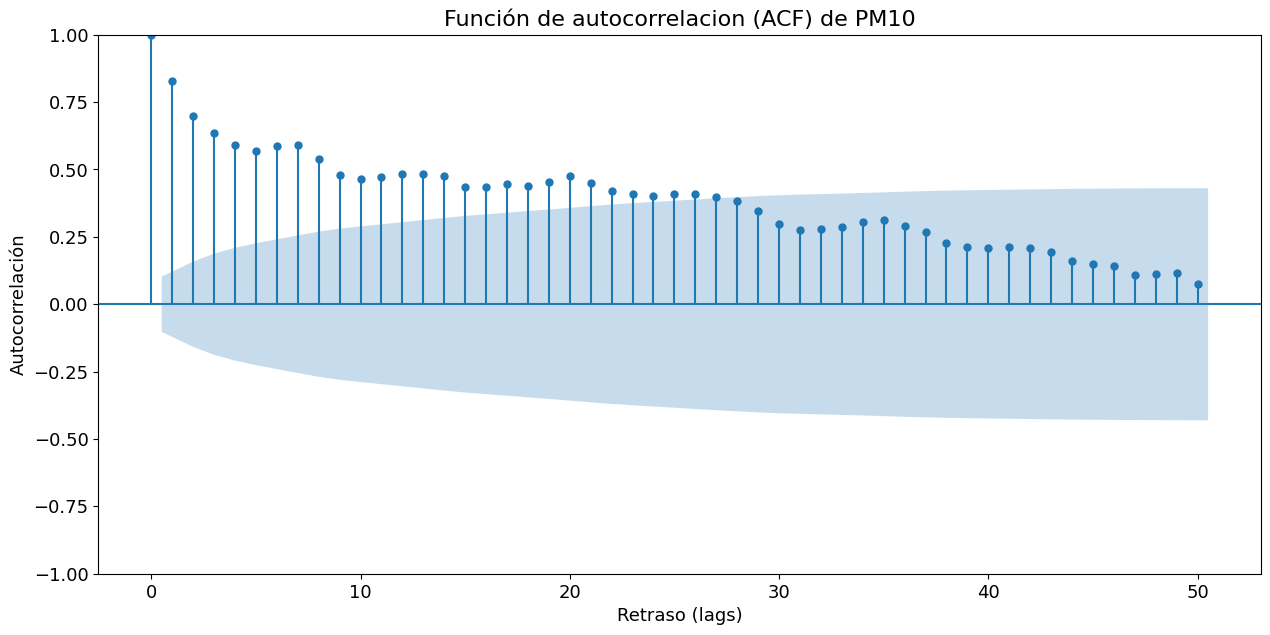

In [89]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(15,7), dpi=100)

plot_acf(serie, lags=50, ax=ax)
ax.set_title('Función de autocorrelacion (ACF) de PM10', fontsize=16)
ax.set_xlabel('Retraso (lags)', fontsize=13)
ax.set_ylabel('Autocorrelación', fontsize=13)
ax.tick_params(labelsize=13)

plt.show()

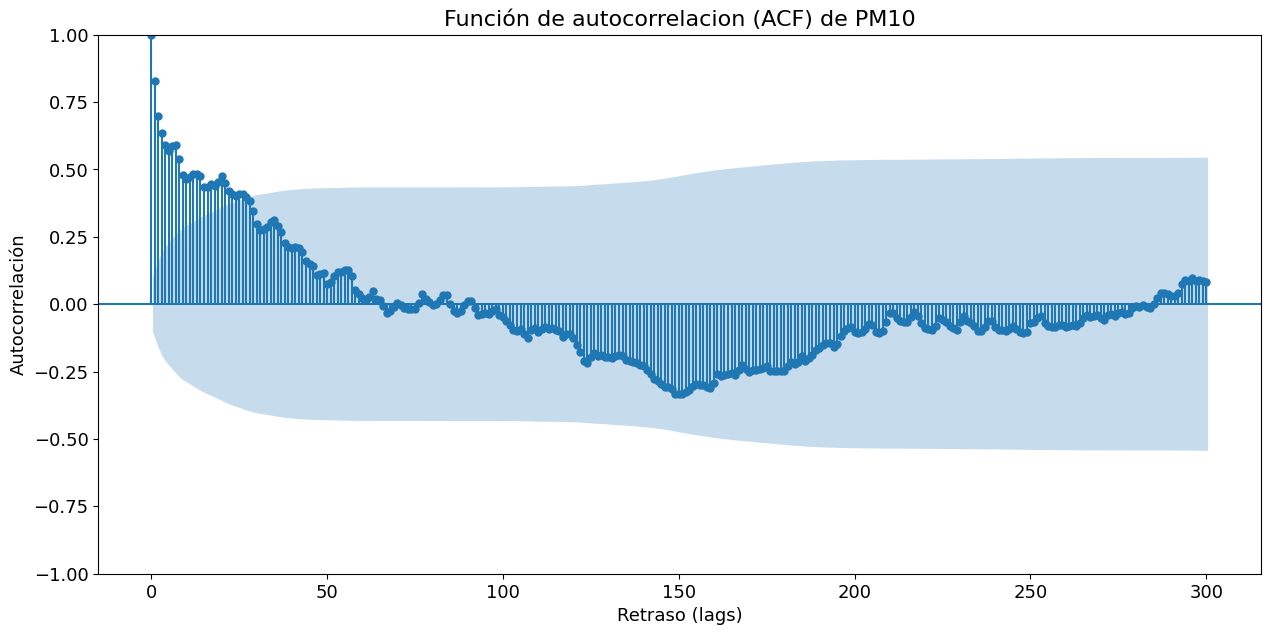

In [97]:
fig, ax = plt.subplots(figsize=(15,7), dpi=100)

plot_acf(serie, lags=300, ax=ax)
ax.set_title('Función de autocorrelacion (ACF) de PM10', fontsize=16)
ax.set_xlabel('Retraso (lags)', fontsize=13)
ax.set_ylabel('Autocorrelación', fontsize=13)
ax.tick_params(labelsize=13)

plt.show()

In [99]:
df.columns #nombre de las columnas

Index(['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2'], dtype='object')

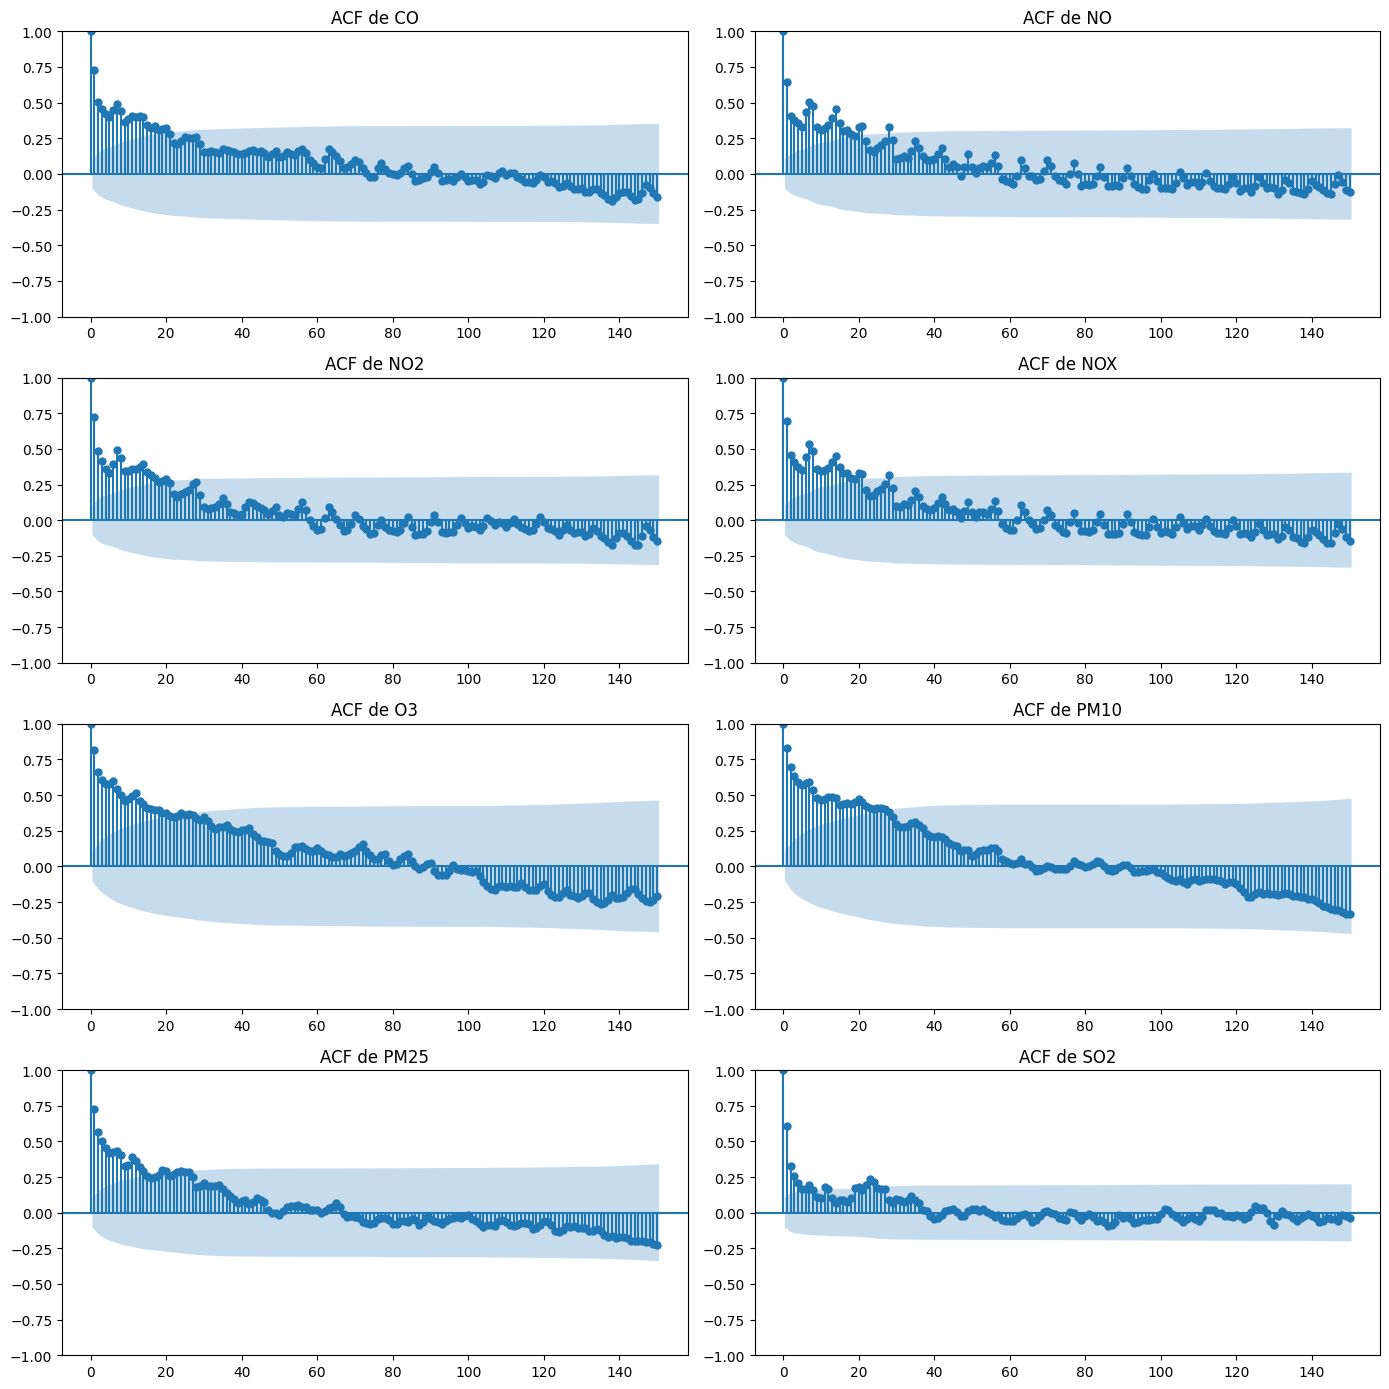

In [103]:
variables =['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,14))
axes=axes.flatten()

for i, var in enumerate(variables):
    plot_acf(df[var].dropna(), lags=150, ax=axes[i])
    axes[i].set_title(f'ACF de {var}')

plt.tight_layout()
plt.show()